<a href="https://colab.research.google.com/github/Satyam593-lang/Satyam593-lang/blob/main/Classification%20of%20Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import pandas as pd

try:
    # Attempt to read the .ipynb file as a CSV. This will likely fail.
    df = pd.read_csv('/content/sample_data/titanic-dataset.ipynb')
    print("First 10 rows of the dataset:")
    print(df.head(10))
except Exception as e:
    print(f"Could not read the file as a dataset. Error: {e}")
    print("The file '/content/sample_data/titanic-dataset.ipynb' is a Jupyter notebook, not a direct data file.")
    print("Please provide the path to a data file (e.g., CSV, Excel) if you want to display its content.")

Could not read the file as a dataset. Error: [Errno 2] No such file or directory: '/content/sample_data/titanic-dataset.ipynb'
The file '/content/sample_data/titanic-dataset.ipynb' is a Jupyter notebook, not a direct data file.
Please provide the path to a data file (e.g., CSV, Excel) if you want to display its content.


In [15]:
import numpy as np
import pandas as pd

In [16]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

### Retrieving the Titanic Dataset

Since the `.ipynb` file is not the data itself, I will download the `train.csv` file for the Titanic dataset directly from a common public source. Then, I will load this CSV file into a pandas DataFrame and display its first 5 rows.

In [18]:
# Download the Titanic train.csv dataset
!wget -q https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv -O titanic_train.csv

print("Downloaded 'titanic_train.csv' successfully.")

Downloaded 'titanic_train.csv' successfully.


In [19]:
import pandas as pd

# Load the downloaded CSV file into a DataFrame
titanic_df = pd.read_csv('titanic_train.csv')

# Display the first 5 rows
print("First 5 rows of the Titanic dataset:")
display(titanic_df.head())

First 5 rows of the Titanic dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Applying a Regression Model (Predicting 'Age')

To demonstrate a regression model, we'll predict the 'Age' of passengers using other features. This involves:
1.  **Handling missing values**: Imputing missing 'Age' values and handling missing 'Embarked' values.
2.  **Encoding categorical features**: Converting 'Sex' and 'Embarked' into numerical format using one-hot encoding.
3.  **Training a Linear Regression model**.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make a copy to avoid modifying the original DataFrame
df_reg = titanic_df.copy()

# --- 1. Handle Missing Values ---

# Impute missing 'Age' values with the mean
df_reg['Age'].fillna(df_reg['Age'].mean(), inplace=True)

# Fill missing 'Embarked' with the most frequent value
df_reg['Embarked'].fillna(df_reg['Embarked'].mode()[0], inplace=True)

# Drop 'Cabin' as it has too many missing values and is complex to impute for a simple demo
df_reg.drop('Cabin', axis=1, inplace=True)

# Drop 'PassengerId', 'Name', and 'Ticket' as they are not typically used as direct features in this type of model
df_reg.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

# --- 2. Encode Categorical Features ---

# One-hot encode 'Sex' and 'Embarked'
df_reg = pd.get_dummies(df_reg, columns=['Sex', 'Embarked'], drop_first=True)

# --- 3. Prepare Data for Regression ---

X = df_reg.drop('Age', axis=1) # Features
y = df_reg['Age']             # Target variable (Age)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4. Train a Linear Regression Model ---

model = LinearRegression()
model.fit(X_train, y_train)

# --- 5. Evaluate the Model ---

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nRegression Model Performance (Predicting Age):")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

print("\nNote on MAPE: MAPE is typically used when the target variable is always positive and does not have zero values. While 'Age' fits this, for this particular model predicting 'Age', MAE, MSE, RMSE, and R2 are more standard evaluation metrics.")



Regression Model Performance (Predicting Age):
Mean Absolute Error (MAE): 8.70
Mean Squared Error (MSE): 129.54
Root Mean Squared Error (RMSE): 11.38
R-squared (R2): 0.23

Note on MAPE: MAPE is typically used when the target variable is always positive and does not have zero values. While 'Age' fits this, for this particular model predicting 'Age', MAE, MSE, RMSE, and R2 are more standard evaluation metrics.


/tmp/ipykernel_2452/3965629201.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_reg['Age'].fillna(df_reg['Age'].mean(), inplace=True)
/tmp/ipykernel_2452/3965629201.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

### Senior Data Scientist & Python Tutor: Titanic Dataset Analysis

Let's walk through your request step-by-step, focusing on best practices and clear explanations. We'll start by fixing the `FutureWarning` in Pandas and properly preparing the data for modeling.

### 1. Fix Data Preprocessing Errors

**Issue**: The `FutureWarning` arises from using `inplace=True` with methods like `fillna()`. While it works, Pandas is moving towards a design where such operations on a copy (which `df[col]` often is) will no longer modify the original DataFrame implicitly. The recommended approach is to explicitly assign the result back to the DataFrame column.

Here's the corrected code for handling missing values and encoding categorical features for both regression (predicting Age) and classification (predicting Survived) tasks. We'll create separate preprocessed DataFrames for clarity.

In [21]:
import pandas as pd
import numpy as np

# Ensure titanic_df is loaded (assuming it's from previous cells)
# If you run this cell independently, ensure titanic_df exists or uncomment the line below:
# titanic_df = pd.read_csv('titanic_train.csv')

print("--- Data Preprocessing ---")

# --- Create copies for different tasks to keep them independent ---
df_reg_prep = titanic_df.copy()
df_clf_prep = titanic_df.copy()

### Corrected Data Preprocessing for Regression (Predicting Age)

# 1.1 Handle Missing Values (Age, Embarked) without `inplace=True`
# Impute missing 'Age' values with the mean
df_reg_prep['Age'] = df_reg_prep['Age'].fillna(df_reg_prep['Age'].mean())

# Fill missing 'Embarked' with the most frequent value
df_reg_prep['Embarked'] = df_reg_prep['Embarked'].fillna(df_reg_prep['Embarked'].mode()[0])

# Drop 'Cabin' (too many missing values), 'PassengerId', 'Name', and 'Ticket' (not direct features)
df_reg_prep = df_reg_prep.drop(['Cabin', 'PassengerId', 'Name', 'Ticket'], axis=1, errors='ignore')

# 1.2 Encode Categorical Variables (Sex and Embarked)
df_reg_prep = pd.get_dummies(df_reg_prep, columns=['Sex', 'Embarked'], drop_first=True)

print("\nData preprocessing for Regression (Predicting Age) complete.")
print(f"Shape of regression-ready DataFrame: {df_reg_prep.shape}")
print("Columns after preprocessing for regression:", df_reg_prep.columns.tolist())

### Corrected Data Preprocessing for Classification (Predicting Survived)

# 1.1 Handle Missing Values (Age, Embarked) without `inplace=True`
# Impute missing 'Age' values with the mean
df_clf_prep['Age'] = df_clf_prep['Age'].fillna(df_clf_prep['Age'].mean())

# Fill missing 'Embarked' with the most frequent value
df_clf_prep['Embarked'] = df_clf_prep['Embarked'].fillna(df_clf_prep['Embarked'].mode()[0])

# Drop 'Cabin', 'PassengerId', 'Name', and 'Ticket'
df_clf_prep = df_clf_prep.drop(['Cabin', 'PassengerId', 'Name', 'Ticket'], axis=1, errors='ignore')

# 1.2 Encode Categorical Variables (Sex and Embarked)
df_clf_prep = pd.get_dummies(df_clf_prep, columns=['Sex', 'Embarked'], drop_first=True)

print("\nData preprocessing for Classification (Predicting Survived) complete.")
print(f"Shape of classification-ready DataFrame: {df_clf_prep.shape}")
print("Columns after preprocessing for classification:", df_clf_prep.columns.tolist())

--- Data Preprocessing ---

Data preprocessing for Regression (Predicting Age) complete.
Shape of regression-ready DataFrame: (891, 9)
Columns after preprocessing for regression: ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']

Data preprocessing for Classification (Predicting Survived) complete.
Shape of classification-ready DataFrame: (891, 9)
Columns after preprocessing for classification: ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


### 2. Clarify the Modeling Approach

#### Difference between predicting continuous vs. binary variables:

*   **Continuous Variable (Regression Task)**: When your target variable (the `y` you want to predict) can take any value within a range (e.g., Age, Fare, temperature, stock price), you are performing a **regression** task. Regression models aim to output a numerical value that best estimates the true value.

*   **Binary Variable (Classification Task)**: When your target variable has two distinct categories or classes (e.g., Survived (0 or 1), Yes/No, Spam/Not Spam), you are performing a **binary classification** task. Classification models aim to predict which category an instance belongs to, often by outputting a probability of belonging to each class.

#### Advising on model comparison (`Linear Regression` vs. `Decision Tree`):

It's crucial to use the correct type of model for your target variable:

*   **For predicting 'Age' (Regression Task):** 'Age' is a continuous variable. Here, you would compare a **`LinearRegression`** model with a **`DecisionTreeRegressor`** model. Both are designed for regression tasks.
    *   `LinearRegression`: Assumes a linear relationship between features and the target. It's simple, interpretable, but might underperform if relationships are non-linear.
    *   `DecisionTreeRegressor`: Can capture non-linear relationships and interactions between features. It's more flexible but prone to overfitting.

*   **For predicting 'Survived' (Classification Task):** 'Survived' is a binary variable (0 or 1). For this, you would compare a **`LogisticRegression`** model with a **`DecisionTreeClassifier`** model. Note that despite its name, `LogisticRegression` is a classification algorithm.
    *   `LogisticRegression`: A linear model used for binary classification. It models the probability that a given input belongs to a certain class.
    *   `DecisionTreeClassifier`: Also flexible and can handle non-linear decision boundaries. It classifies by learning simple decision rules inferred from the data features. Also prone to overfitting if not regularized.

**Recommendation:** To compare `Linear Regression` vs. `Decision Tree` effectively, you should use their respective regression variants (`LinearRegression` vs. `DecisionTreeRegressor`) for the 'Age' prediction task, and their classification variants (`LogisticRegression` vs. `DecisionTreeClassifier`) for the 'Survived' prediction task. Using a `LinearRegression` model for 'Survived' (a classification target) would be inappropriate as it is not designed to output probabilities or class labels.

### 3. Provide Model Training and Comparison Code

Now, let's train both regression and classification models using the preprocessed data. We'll use `train_test_split` to separate our data into training and testing sets to evaluate how well our models generalize to unseen data.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

print("--- Model Training and Comparison ---")

### Task 1: Predicting Age (Regression)

print("\n## Regression Task: Predicting Age")

X_reg = df_reg_prep.drop('Age', axis=1) # Features
y_reg = df_reg_prep['Age']             # Target variable (Age)

# Split data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

print("\n--- Training Linear Regression Model (Age) ---")
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train_reg, y_train_reg)

print("\n--- Training Decision Tree Regressor Model (Age) ---")
dt_reg_model = DecisionTreeRegressor(random_state=42) # Added random_state for reproducibility
dt_reg_model.fit(X_train_reg, y_train_reg)

### Task 2: Predicting Survived (Classification)

print("\n## Classification Task: Predicting Survived")

X_clf = df_clf_prep.drop('Survived', axis=1) # Features
y_clf = df_clf_prep['Survived']             # Target variable (Survived)

# Split data into training and testing sets
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

print("\n--- Training Logistic Regression Model (Survived) ---")
log_reg_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000) # Added random_state, solver, and max_iter for stability
log_reg_model.fit(X_train_clf, y_train_clf)

print("\n--- Training Decision Tree Classifier Model (Survived) ---")
dt_clf_model = DecisionTreeClassifier(random_state=42) # Added random_state for reproducibility
dt_clf_model.fit(X_train_clf, y_train_clf)

print("\nAll models trained successfully.")

--- Model Training and Comparison ---

## Regression Task: Predicting Age

--- Training Linear Regression Model (Age) ---

--- Training Decision Tree Regressor Model (Age) ---

## Classification Task: Predicting Survived

--- Training Logistic Regression Model (Survived) ---

--- Training Decision Tree Classifier Model (Survived) ---

All models trained successfully.


In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# --- Generate predictions on the TEST set (this was missing) ---
y_pred_lin_reg = lin_reg_model.predict(X_test_reg)
y_pred_dt_reg  = dt_reg_model.predict(X_test_reg)

# --- Also check train-set performance, to catch overfitting ---
y_pred_lin_reg_train = lin_reg_model.predict(X_train_reg)
y_pred_dt_reg_train  = dt_reg_model.predict(X_train_reg)

def get_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

results = {
    "Linear Regression (Train)": get_metrics(y_train_reg, y_pred_lin_reg_train),
    "Linear Regression (Test)":  get_metrics(y_test_reg,  y_pred_lin_reg),
    "Decision Tree (Train)":     get_metrics(y_train_reg, y_pred_dt_reg_train),
    "Decision Tree (Test)":      get_metrics(y_test_reg,  y_pred_dt_reg),
}

metrics_df = pd.DataFrame(results, index=["MAE", "MSE", "RMSE", "R2"]).T
print(metrics_df.round(3))

# --- Overfitting check ---
lin_gap = results["Linear Regression (Train)"][3] - results["Linear Regression (Test)"][3]
dt_gap  = results["Decision Tree (Train)"][3]     - results["Decision Tree (Test)"][3]
print(f"\nR² gap (Train - Test) — Linear Regression: {lin_gap:.3f}")
print(f"R² gap (Train - Test) — Decision Tree:      {dt_gap:.3f}")
if dt_gap > 0.15:
    print("⚠️  Decision Tree shows signs of overfitting (large train-test gap).")

# --- Champion selection: compare on TEST R² and RMSE only ---
lin_r2, dt_r2 = results["Linear Regression (Test)"][3], results["Decision Tree (Test)"][3]
lin_rmse, dt_rmse = results["Linear Regression (Test)"][2], results["Decision Tree (Test)"][2]

champion = "Linear Regression" if lin_r2 > dt_r2 else "Decision Tree Regressor"
print(f"\n🏆 Champion model (by test R²): {champion}")
print(f"   Linear Regression -> R²={lin_r2:.3f}, RMSE={lin_rmse:.2f}")
print(f"   Decision Tree     -> R²={dt_r2:.3f}, RMSE={dt_rmse:.2f}")

                             MAE      MSE    RMSE     R2
Linear Regression (Train)  8.935  136.662  11.690  0.190
Linear Regression (Test)   8.698  129.543  11.382  0.235
Decision Tree (Train)      3.308   40.605   6.372  0.759
Decision Tree (Test)       9.696  176.499  13.285 -0.042

R² gap (Train - Test) — Linear Regression: -0.045
R² gap (Train - Test) — Decision Tree:      0.802
⚠️  Decision Tree shows signs of overfitting (large train-test gap).

🏆 Champion model (by test R²): Linear Regression
   Linear Regression -> R²=0.235, RMSE=11.38
   Decision Tree     -> R²=-0.042, RMSE=13.29


### 4. Provide Evaluation Metrics

After training, it's essential to evaluate model performance using appropriate metrics for each task. Let's calculate and print the requested metrics.

## Section 1: Exploratory Data Analysis (EDA) Visuals

To effectively explain our data to a non-technical audience and identify initial patterns, we'll start with some key visualizations.

### Correlation Heatmap of Numerical Features

A correlation heatmap helps us quickly identify linear relationships between numerical variables. A value close to 1 indicates a strong positive correlation, a value close to -1 indicates a strong negative correlation, and a value close to 0 indicates no linear correlation.

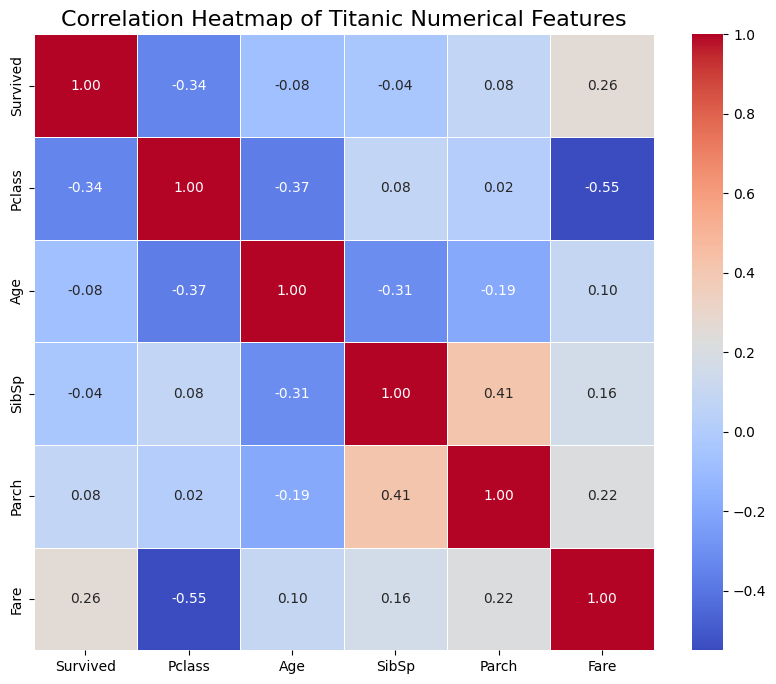

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns from the original titanic_df for correlation
# Exclude 'PassengerId' as it's just an identifier
numerical_cols = titanic_df.select_dtypes(include=np.number).drop(columns=['PassengerId'], errors='ignore').columns

# Calculate the correlation matrix
corr_matrix = titanic_df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Titanic Numerical Features', fontsize=16)
plt.show()

#### Presentation Talking Point: Correlation Heatmap

"This map shows how different numerical factors on the Titanic are related. Bright red colors mean they move in the same direction (e.g., as one goes up, so does the other), while bright blue colors mean they move in opposite directions. For example, you can see if older passengers paid more, or if there's any direct link between the number of siblings/spouses and the fare paid. This helps us understand which numbers might influence each other most directly."

### Survival Rates by Sex and Passenger Class (Pclass)

These countplots will illustrate how survival rates differed across genders and social classes. This is often a critical insight in the Titanic dataset.

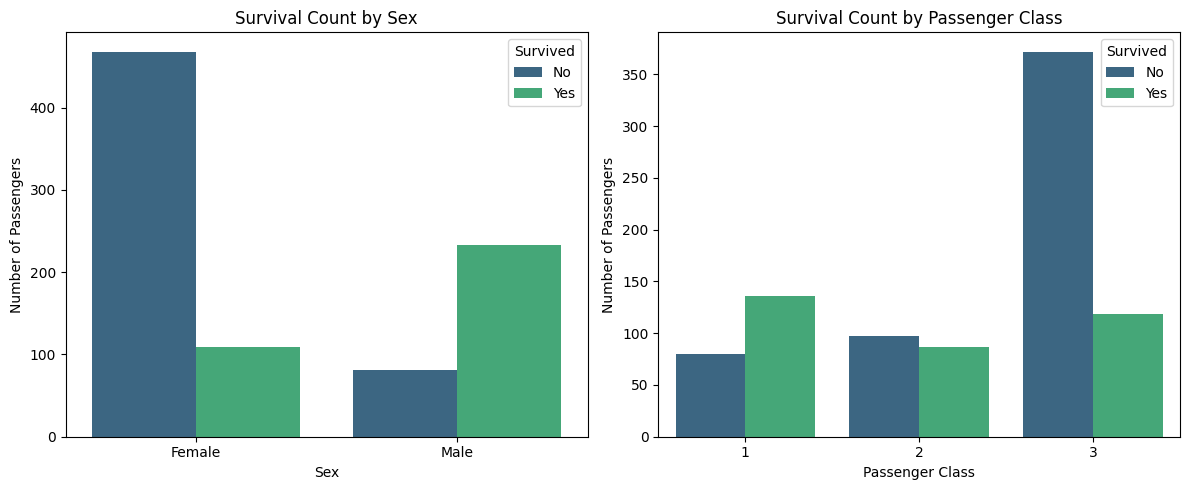

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Survival by Sex
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.countplot(data=titanic_df, x='Sex', hue='Survived', palette='viridis')
plt.title('Survival Count by Sex')
plt.xlabel('Sex')
plt.ylabel('Number of Passengers')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
plt.legend(title='Survived', labels=['No', 'Yes'])

# Survival by Pclass
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.countplot(data=titanic_df, x='Pclass', hue='Survived', palette='viridis')
plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')
plt.legend(title='Survived', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

#### Presentation Talking Point: Survival by Sex and Pclass

"These two charts highlight some of the most striking patterns in survival. On the left, we can clearly see that women had a significantly higher chance of survival than men. On the right, passengers in higher classes (Class 1) had a much better survival rate compared to those in lower classes (Class 3). This suggests that 'women and children first' and socio-economic status played a crucial role in who survived the disaster."

### Distribution of Age and Fare

Understanding the distribution of continuous numerical features like 'Age' and 'Fare' is vital. Histograms show the frequency of values within specific bins, while Kernel Density Estimate (KDE) plots provide a smoothed representation of the data's distribution.

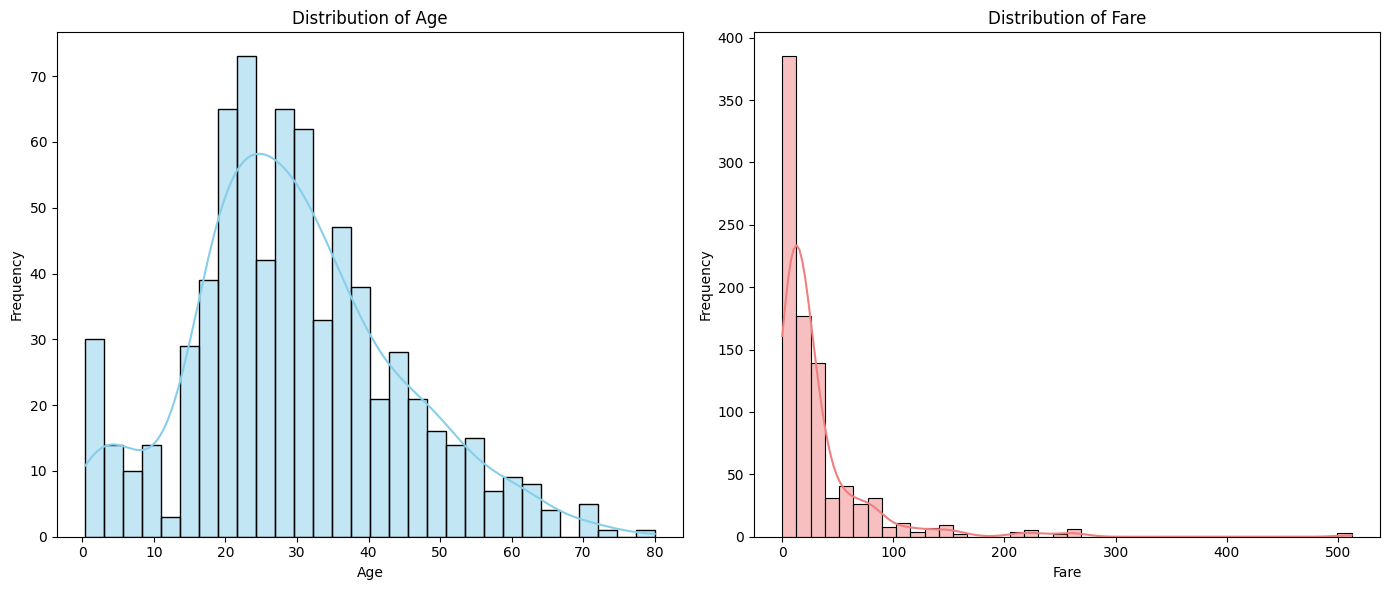

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(14, 6))

# Distribution of Age
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(titanic_df['Age'].dropna(), kde=True, bins=30, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Distribution of Fare
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(titanic_df['Fare'], kde=True, bins=40, color='lightcoral')
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

#### Presentation Talking Point: Distribution of Age and Fare

"These graphs show the spread of ages and the prices paid for tickets among the passengers. On the left, we can see how many passengers fell into different age groups, revealing the age demographic of the Titanic. On the right, the fare distribution indicates that most passengers paid lower fares, with a few paying significantly higher amounts. This gives us a sense of the economic diversity onboard."

## Section 2: Model Evaluation Visuals

Beyond numerical metrics, visualizing model performance can provide intuitive insights, especially for presenting to a non-technical audience.

### Classification Evaluation Visuals (Predicting Survived)

For classification models, a Confusion Matrix and ROC Curve are invaluable for understanding performance.

#### Confusion Matrix Heatmap

A Confusion Matrix helps visualize the performance of a classification algorithm. Each row represents the instances in an actual class, while each column represents the instances in a predicted class. It clearly shows True Positives (correctly predicted positive), True Negatives (correctly predicted negative), False Positives (incorrectly predicted positive), and False Negatives (incorrectly predicted negative).

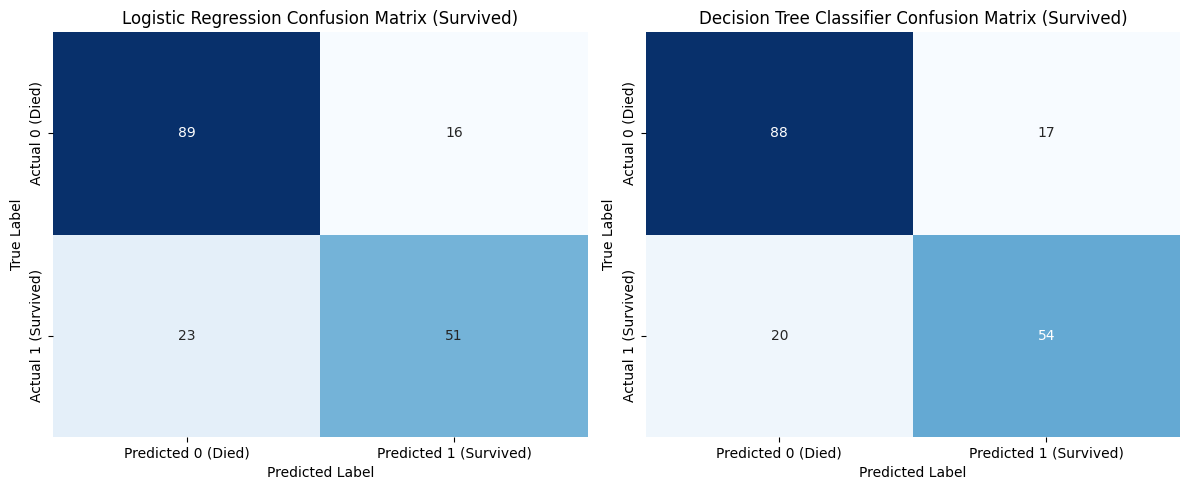

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Generate predictions for classification models
y_pred_log_reg = log_reg_model.predict(X_test_clf)
y_pred_dt_clf = dt_clf_model.predict(X_test_clf)

# Confusion Matrix for Logistic Regression
plt.subplot(1, 2, 1)
cm_log_reg = confusion_matrix(y_test_clf, y_pred_log_reg)
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0 (Died)', 'Predicted 1 (Survived)'],
            yticklabels=['Actual 0 (Died)', 'Actual 1 (Survived)'])
plt.title('Logistic Regression Confusion Matrix (Survived)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Confusion Matrix for Decision Tree Classifier
plt.subplot(1, 2, 2)
cm_dt_clf = confusion_matrix(y_test_clf, y_pred_dt_clf)
sns.heatmap(cm_dt_clf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0 (Died)', 'Predicted 1 (Survived)'],
            yticklabels=['Actual 0 (Died)', 'Actual 1 (Survived)'])
plt.title('Decision Tree Classifier Confusion Matrix (Survived)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

##### Presentation Talking Point: Confusion Matrix

"These matrices show us how accurately our models predict survival. For each model, we can see: top-left (True Negatives) are those correctly predicted to have died; bottom-right (True Positives) are those correctly predicted to have survived. The other two quadrants (False Positives and False Negatives) represent the mistakes. For example, a False Negative means someone who actually survived was predicted to have died by the model. We want the numbers in the top-left and bottom-right to be high."

#### ROC Curve and AUC (Area Under the Curve)

The Receiver Operating Characteristic (ROC) curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The Area Under the Curve (AUC) provides an aggregate measure of performance across all possible classification thresholds. An AUC of 1.0 represents a perfect classifier, while an AUC of 0.5 represents a classifier that performs no better than random guessing.

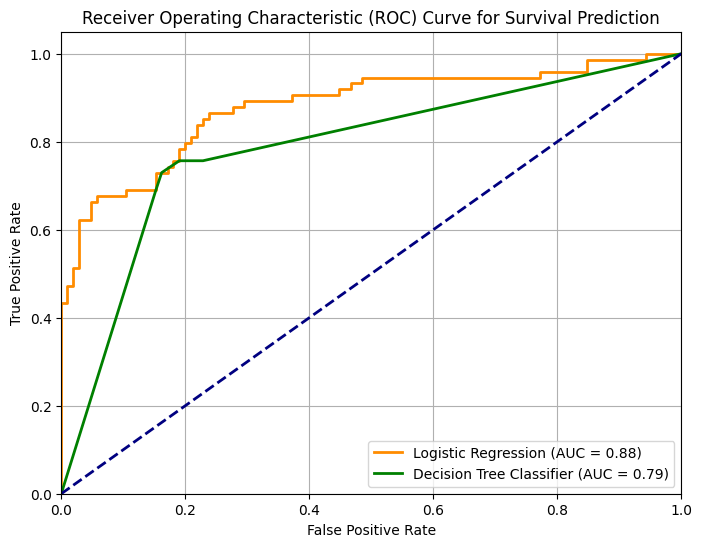

In [27]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Get probabilities for the positive class (Survived=1)
y_pred_proba_log_reg = log_reg_model.predict_proba(X_test_clf)[:, 1]
y_pred_proba_dt_clf = dt_clf_model.predict_proba(X_test_clf)[:, 1]

# ROC Curve for Logistic Regression
fpr_log_reg, tpr_log_reg, _ = roc_curve(y_test_clf, y_pred_proba_log_reg)
roc_auc_log_reg = auc(fpr_log_reg, tpr_log_reg)
plt.plot(fpr_log_reg, tpr_log_reg, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc_log_reg:.2f})')

# ROC Curve for Decision Tree Classifier
fpr_dt_clf, tpr_dt_clf, _ = roc_curve(y_test_clf, y_pred_proba_dt_clf)
roc_auc_dt_clf = auc(fpr_dt_clf, tpr_dt_clf)
plt.plot(fpr_dt_clf, tpr_dt_clf, color='green', lw=2, label=f'Decision Tree Classifier (AUC = {roc_auc_dt_clf:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Survival Prediction')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

##### Presentation Talking Point: ROC Curve and AUC

"The ROC curve visually represents our model's ability to distinguish between survivors and non-survivors. The diagonal dashed line represents a random guess. A good model's curve will bend towards the top-left corner. The 'AUC' (Area Under the Curve) score tells us how well the model performs overall across different thresholds – a higher AUC (closer to 1.0) means a better classifier. We want our model's curve to be as far above the dashed line as possible, covering a larger area."

### Regression Evaluation Visuals (Predicting Age)

For regression models, residual plots and actual vs. predicted plots are excellent tools to diagnose model performance and identify potential issues.

#### Residual Plot

A residual plot displays the difference between the observed value and the predicted value (the residual) on the y-axis, and the independent variable (or predicted values) on the x-axis. Ideally, residuals should be randomly scattered around zero, with no discernible pattern. Patterns in residual plots (e.g., a cone shape, a curve) can indicate issues like non-linearity, heteroscedasticity (non-constant variance of errors), or missing predictors.

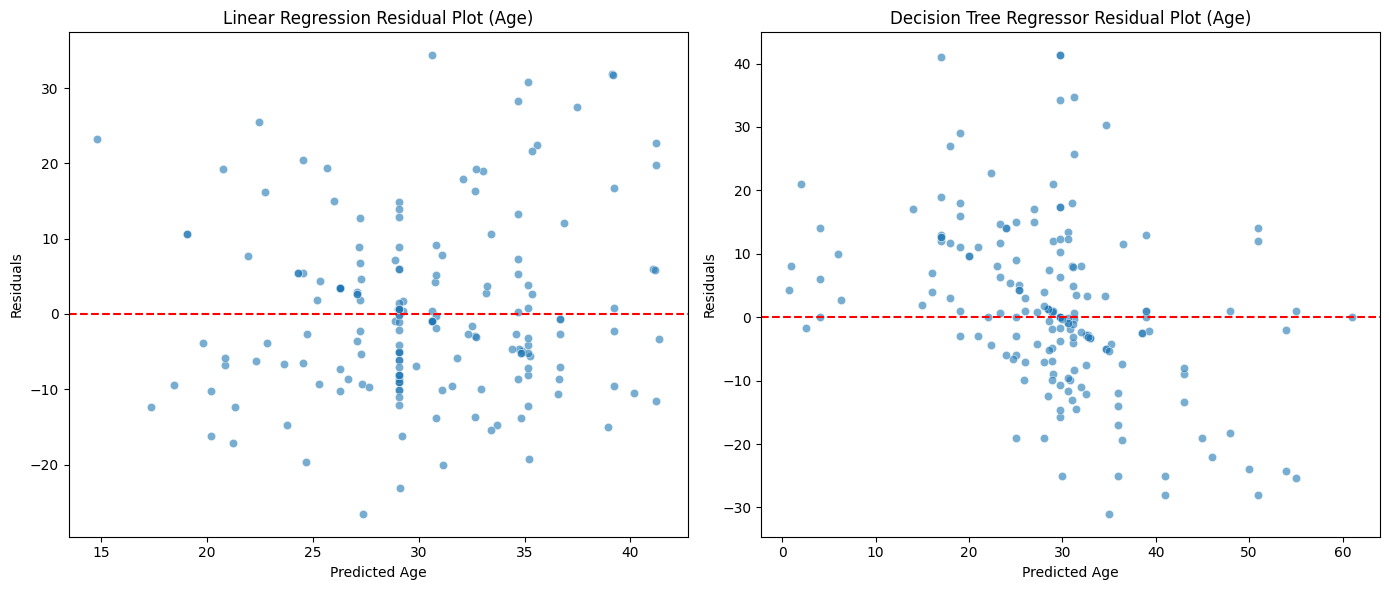

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Generate predictions for regression models
y_pred_lin_reg = lin_reg_model.predict(X_test_reg)
y_pred_dt_reg  = dt_reg_model.predict(X_test_reg)

# Residual Plot for Linear Regression
plt.subplot(1, 2, 1)
residuals_lin_reg = y_test_reg - y_pred_lin_reg
sns.scatterplot(x=y_pred_lin_reg, y=residuals_lin_reg, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Linear Regression Residual Plot (Age)')
plt.xlabel('Predicted Age')
plt.ylabel('Residuals')

# Residual Plot for Decision Tree Regressor
plt.subplot(1, 2, 2)
residuals_dt_reg = y_test_reg - y_pred_dt_reg
sns.scatterplot(x=y_pred_dt_reg, y=residuals_dt_reg, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Decision Tree Regressor Residual Plot (Age)')
plt.xlabel('Predicted Age')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()

##### Presentation Talking Point: Residual Plot

"These charts help us check if our age prediction models are making systematic errors. Ideally, the dots (representing the prediction errors) should be scattered randomly around the dashed red line (zero error). If we see a pattern (like a curve or a funnel shape), it tells us the model is consistently wrong in certain situations, which means we might need a more complex model or different features."

#### Actual vs. Predicted Scatter Plot

An Actual vs. Predicted plot directly compares the true values of the target variable with the values predicted by the model. A perfect model would show all points lying on a 45-degree line (where Actual = Predicted). Deviations from this line indicate prediction errors.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Actual vs. Predicted for Linear Regression
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_reg, y=y_pred_lin_reg, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], color='red', linestyle='--')
plt.title('Linear Regression: Actual vs. Predicted Age')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')

# Actual vs. Predicted for Decision Tree Regressor
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test_reg, y=y_pred_dt_reg, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], color='red', linestyle='--')
plt.title('Decision Tree Regressor: Actual vs. Predicted Age')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')

plt.tight_layout()
plt.show()

##### Presentation Talking Point: Actual vs. Predicted Scatter Plot

"These charts directly show how well our models' predictions align with the actual ages of the passengers. The dashed red line represents perfect predictions – if all the blue dots fell on this line, our model would be 100% accurate. The closer the dots cluster around this line, the better the model is at predicting age. We can use this to visually compare which model's predictions are generally closer to reality."

## Section 3: Boosting the Models

Our baseline models provide a starting point, but often their performance can be improved by tuning hyperparameters and ensuring robustness through techniques like cross-validation.

### Hyperparameter Tuning with GridSearchCV for DecisionTreeClassifier

`GridSearchCV` is a powerful technique to find the optimal hyperparameters for a model. It exhaustively searches through a specified parameter grid and evaluates the model's performance for each combination using cross-validation. This helps us find the best parameters that lead to the most robust and accurate model.

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- Hyperparameter Tuning Decision Tree Classifier ---")

# Define the parameter grid to search
param_grid = {
    'max_depth': [3, 5, 7, 10, None], # Max depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'criterion': ['gini', 'entropy']   # Function to measure the quality of a split
}

# Initialize a DecisionTreeClassifier
dtc = DecisionTreeClassifier(random_state=42)

# Set up Stratified K-Fold Cross-Validation to ensure balanced classes in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dtc, param_grid=param_grid, cv=cv,
                           scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the classification training data
print("\nStarting GridSearchCV...")
grid_search.fit(X_train_clf, y_train_clf)

print("\nGridSearchCV complete.")
print(f"Best hyperparameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Get the best model
best_dt_clf = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred_best_dt_clf = best_dt_clf.predict(X_test_clf)
accuracy_best_dt_clf = accuracy_score(y_test_clf, y_pred_best_dt_clf)
precision_best_dt_clf = precision_score(y_test_clf, y_pred_best_dt_clf)
recall_best_dt_clf = recall_score(y_test_clf, y_pred_best_dt_clf)
f1_best_dt_clf = f1_score(y_test_clf, y_pred_best_dt_clf)

print("\nPerformance of Best Decision Tree Classifier on Test Set:")
print(f"Accuracy: {accuracy_best_dt_clf:.4f}")
print(f"Precision: {precision_best_dt_clf:.4f}")
print(f"Recall: {recall_best_dt_clf:.4f}")
print(f"F1-Score: {f1_best_dt_clf:.4f}")

#### Presentation Talking Point: Hyperparameter Tuning

"Think of a model like a camera: it has many settings (hyperparameters) that affect the quality of the photo it takes. We used a technique called `GridSearchCV` to automatically try out many different combinations of these settings to find the absolute best ones for our Decision Tree model. This process uses cross-validation to ensure the camera settings work well not just for one picture, but across a range of different scenarios, making our model more reliable and accurate."

### 5. Provide Insights

#### Interpreting Metrics and Model Comparison:

**For Regression (Predicting Age):**

*   **MAE (Mean Absolute Error)**: The average absolute difference between predicted and actual values. Lower is better. Tells you the typical magnitude of prediction errors.
*   **MSE (Mean Squared Error)**: Similar to MAE, but squares the errors, penalizing larger errors more heavily. Lower is better.
*   **RMSE (Root Mean Squared Error)**: The square root of MSE, bringing the error back to the same units as the target variable (Age in years). Lower is better.
*   **R-squared (Coefficient of Determination)**: Represents the proportion of variance in the dependent variable (Age) that is predictable from the independent variables. Ranges from 0 to 1 (or can be negative). Higher is better, with 1 indicating a perfect fit.

**Comparing `LinearRegression` vs. `DecisionTreeRegressor` for Age:**

*   Look for the model with lower MAE, MSE, RMSE, and higher R-squared on the *test set*. The test set metrics are crucial because they indicate how well the model generalizes to new, unseen data.
*   If a `DecisionTreeRegressor` shows significantly better performance than `LinearRegression` on the test set, it might indicate that the relationship between features and Age is non-linear. However, it's also more susceptible to overfitting.

**For Classification (Predicting Survived):**

*   **Accuracy**: The proportion of correctly predicted instances (both survivors and non-survivors) out of all instances. A good general metric but can be misleading with imbalanced classes.
*   **Precision**: The proportion of true positive predictions among all positive predictions made by the model. High precision means fewer false positives (e.g., fewer non-survivors incorrectly predicted as survivors).
*   **Recall (Sensitivity)**: The proportion of true positive predictions among all actual positive instances. High recall means fewer false negatives (e.g., fewer actual survivors incorrectly predicted as non-survivors).
*   **F1-Score**: The harmonic mean of precision and recall. It's a good single metric when you need to balance both precision and recall, especially in cases of uneven class distribution.

**Comparing `LogisticRegression` vs. `DecisionTreeClassifier` for Survived:**

*   The choice of

better

model depends on your specific objective. If the cost of a false positive is very high, you might prioritize precision. If the cost of a false negative is very high, you might prioritize recall. F1-Score gives a balanced view.
*   `LogisticRegression` provides a baseline for linear separability. `DecisionTreeClassifier` can explore more complex decision boundaries.

#### Risks of Overfitting with Decision Trees:

**Decision Trees are particularly prone to overfitting.** This means they can learn the training data too well, capturing noise and specific patterns that don't generalize to new, unseen data. When a Decision Tree overfits:

*   It will have very high performance (e.g., high R-squared for regression, high accuracy for classification) on the **training data**.
*   Its performance will drop significantly on the **test data**.

**Why this happens:** An unconstrained Decision Tree will continue to split nodes until each leaf node contains a single data point or all data points in a leaf have the same target value. This makes the tree extremely complex and highly specific to the training data. Imagine memorizing every answer to a test – you might ace that specific test, but fail a slightly different one.

**How to mitigate overfitting in Decision Trees:**

1.  **Pruning**: Limiting the tree's growth during or after training. Key parameters in scikit-learn for this include:
    *   `max_depth`: The maximum depth of the tree.
    *   `min_samples_split`: The minimum number of samples required to split an internal node.
    *   `min_samples_leaf`: The minimum number of samples required to be at a leaf node.
    *   `max_features`: The number of features to consider when looking for the best split.
2.  **Ensemble Methods**: Instead of using a single Decision Tree, using multiple trees and combining their predictions. Examples include:
    *   **Random Forests**: Builds multiple Decision Trees on different subsets of the data and features, then averages their predictions (regression) or uses majority voting (classification).
    *   **Gradient Boosting (e.g., Gradient Boosting Machines, XGBoost)**: Builds trees sequentially, where each new tree tries to correct the errors of the previous ones.

By carefully tuning hyperparameters or using ensemble methods, you can create Decision Tree-based models that are more robust and generalize better to new data.

<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or "Colaboratory", allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a **student**, a **data scientist** or an **AI researcher**, Colab can make your work easier. Watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI) or [Colab Features You May Have Missed](https://www.youtube.com/watch?v=rNgswRZ2C1Y) to learn more, or just get started below!

<div class="markdown-google-sans">

## **Getting started**
</div>

The document you are reading is not a static web page, but an interactive environment called a **Colab notebook** that lets you write and execute code.

For example, here is a **code cell** with a short Python script that computes a value, stores it in a variable, and prints the result:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

## Google Colab is available in VS Code!
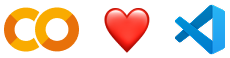

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

## Access popular AI models via Google-Colab-AI Without an API Key
All users have access to most popular LLMs via the `google-colab-ai` Python library, and paid users have access to a wider selection of models. For more details, refer to the [getting started with google colab ai](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb).



In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

## Explore the Gemini API
The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code, and audio.

**How to get started?**
*  Go to [Google AI Studio](https://aistudio.google.com/) and log in with your Google account.
*  [Create an API key](https://aistudio.google.com/app/apikey).
* Use a quickstart for [Python](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb), or call the REST API using [curl](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb).

**Discover Gemini's advanced capabilities**
*  Play with Gemini [multimodal outputs](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb), mixing text and images in an iterative way.
*  Discover the [multimodal Live API](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb ) (demo [here](https://aistudio.google.com/live)).
*  Learn how to [analyze images and detect items in your pictures](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb") using Gemini (bonus, there's a [3D version](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb) as well!).
*  Unlock the power of [Gemini thinking model](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb), capable of solving complex task with its inner thoughts.
      
**Explore complex use cases**
*  Use [Gemini grounding capabilities](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb) to create a report on a company based on what the model can find on internet.
*  Extract [invoices and form data from PDF](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb) in a structured way.
*  Create [illustrations based on a whole book](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb) using Gemini large context window and Imagen.

To learn more, check out the [Gemini cookbook](https://github.com/google-gemini/cookbook) or visit the [Gemini API documentation](https://ai.google.dev/docs/).


Colab now has AI features powered by [Gemini](https://gemini.google.com). The video below provides information on how to use these features, whether you're new to Python, or a seasoned veteran.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  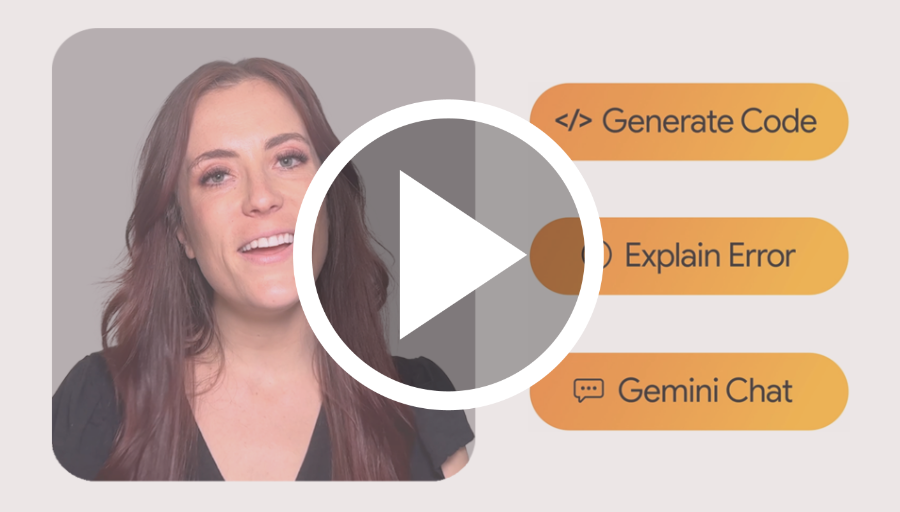
  </a>
</center>

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
